In [ ]:
# TODO: clean up code
# TODO: review reshapes vs views
# TODO: review permutes
# TODO: go deeper by removing F. and nn layers
# TODO: how to increase sample efficiency with stride
# TODO: can we use openwebtext?
# TODO: count model params, count number tokens, do chinchila math
# TODO: check dropout in action
# TODO: manual dropout implementation, check we have same results
# TODO: try removing special chars (replacing with closest)
# TODO: try word tokenization
# TODO: try subword tokenization (lowercase)
# TODO: try custom tokenization
# TODO: inference should only require previous hidden state, not the whole token sequence
# TODO: test if perplexity is constant when loss ranges are different
# TODO: measure token/s during training (take into account block size, batch size, gradient checkpointing, etc)

In [187]:
# NOTE: this config reaches 1.232 val loss on LOTR
CONFIG = {
    "seed" : 42,
    "block_size" : 64, # TODO: increase block size?
    "n_embed" : 128, # TODO: decrease embed size?
    "batch_size" : 64,
    "hidden_size" : 1024,
    "n_epochs" : 50,
    "learning_rate" : 0.5e-3,
    "patience" : 3,
    "early_stop_threshold" : 0.001,
    "dropout" : 0.2
}

In [188]:
from lightning.pytorch import seed_everything

seed_everything(CONFIG["seed"], workers=True)

Seed set to 42


42

In [189]:
import torch
DEVICE = torch.device("mps")

In [ ]:
with open("data/lotr.txt", "r", encoding="utf-8") as f: TEXT = f.read()
TEXT = TEXT.lower()
TEXT[:10000]

'new: dotimsoied edition \n\nadolf hitler \n\n\n"..i could see the \npates had decreed \nmy destiny.." \n\n"hitler \n\nthis l» the boc* \nwritten by adcll mite-* \nlllert ileii krvr.rnwy \nsan^ejk iiir* \nmvri.ilrtrt in iimi (jew, \neany to umlarauru \ncorrrtjnm, accurate \nand uncentorcd ford \ntrarnfalton \n\nhis own words tell \nmore than you have \nheard anymtxtre els* \n\n\ni\' cw e-.»rv >r> o.vr • y »«v - \n\nmmrtv««>tl **■! mwy.»> \n\nvvhwwvl •eno\'cr m^e-xont/rntr »wj« * \n\nertj * m o lkt>j 4 \n\nii n1» fv^ yw h \'?•. ^jp f>«1- ’jc thw* \n\n\nmein kampf \n\nby \n\nadolf hitler \n\n\nford translation \n\n\n\nthis pdf contains the ford translation of mein kampf by adolf hitler. go \nto http://www.hitler-library.org to read about and to purchase the printed \nedition and the audio book. \n\n\n\ncontents \n\n\nforward \n\ndedication \n\n\nfirst volume: an accounting \n\n1. childhood flome \n\n2. years of learning and suffering in vienna \n\n3. general political considerations of m

In [191]:
VOCAB = sorted(list(set(TEXT)))
CONFIG["vocab_size"] = len(VOCAB)
len(VOCAB), VOCAB

(66,
 ['\n',
  ' ',
  '!',
  '"',
  '%',
  "'",
  '(',
  ')',
  '*',
  ',',
  '-',
  '.',
  '/',
  '0',
  '1',
  '2',
  '3',
  '4',
  '5',
  '6',
  '7',
  '8',
  '9',
  ':',
  ';',
  '>',
  '?',
  '[',
  ']',
  '^',
  'a',
  'b',
  'c',
  'd',
  'e',
  'f',
  'g',
  'h',
  'i',
  'j',
  'k',
  'l',
  'm',
  'n',
  'o',
  'p',
  'q',
  'r',
  's',
  't',
  'u',
  'v',
  'w',
  'x',
  'y',
  'z',
  '{',
  '«',
  '¬',
  '»',
  '—',
  '’',
  '“',
  '”',
  '•',
  '■'])

In [192]:
import unicodedata

# Optional extra mappings for characters that normalization may drop
EXTRA_MAP = {
    "ð": "d",
    "þ": "th",
    "ß": "ss",
    "ø": "o",
    "ł": "l",
    "⁄": "/",
}

def to_ascii(text: str) -> str:
    # First, apply manual replacements
    for k, v in EXTRA_MAP.items():
        text = text.replace(k, v)

    # Normalize and strip accents
    normalized = unicodedata.normalize("NFKD", text)
    ascii_text = normalized.encode("ascii", "ignore").decode("ascii")

    return ascii_text

print(to_ascii("áâä éêë íî ð óô úû ý ⁄ café naïve"))

aaa eee ii d oo uu y / cafe naive


In [193]:
TEXT_ASCII = to_ascii(TEXT)
VOCAB = sorted(list(set(TEXT_ASCII)))
CONFIG["vocab_size"] = len(VOCAB)
len(VOCAB), VOCAB

(57,
 ['\n',
  ' ',
  '!',
  '"',
  '%',
  "'",
  '(',
  ')',
  '*',
  ',',
  '-',
  '.',
  '/',
  '0',
  '1',
  '2',
  '3',
  '4',
  '5',
  '6',
  '7',
  '8',
  '9',
  ':',
  ';',
  '>',
  '?',
  '[',
  ']',
  '^',
  'a',
  'b',
  'c',
  'd',
  'e',
  'f',
  'g',
  'h',
  'i',
  'j',
  'k',
  'l',
  'm',
  'n',
  'o',
  'p',
  'q',
  'r',
  's',
  't',
  'u',
  'v',
  'w',
  'x',
  'y',
  'z',
  '{'])

In [194]:
ctoi = dict((c, i) for i, c in enumerate(VOCAB))
itoc = dict((i, c) for i, c in enumerate(VOCAB))
encode = lambda str: [ctoi[c] for c in str]
decode = lambda tokens: "".join([itoc[i] for i in tokens])
decode(encode("hello world"))

'hello world'

In [195]:
#import tiktoken
#enc = tiktoken.get_encoding("gpt2")
#CONFIG["vocab_size"] = enc.n_vocab
#encode = enc.encode
#decode = enc.decode
#enc.n_vocab, decode(encode("hello world"))

In [196]:
TOKENS = encode(TEXT_ASCII)
TOKENS[:10]

[43, 34, 52, 23, 1, 33, 44, 49, 38, 42]

In [197]:
import torch
from torch.utils.data import Dataset

class ChunkedDataset(Dataset):
    def __init__(self, tokens, block_size=CONFIG["block_size"]):
        tokens = torch.tensor(tokens)

        n_chunks = (len(tokens)) // (block_size + 1)
        tokens = tokens[:n_chunks * (block_size + 1)]

        self.chunks = tokens.view(n_chunks, block_size + 1)

    def __getitem__(self, idx):
        chunk = self.chunks[idx]
        x = chunk[:-1]
        y = chunk[1:]
        return x, y

    def __len__(self):
        return len(self.chunks)

full_dataset = ChunkedDataset(TOKENS)
full_dataset[0]

(tensor([43, 34, 52, 23,  1, 33, 44, 49, 38, 42, 48, 44, 38, 34, 33,  1, 34, 33,
         38, 49, 38, 44, 43,  1,  0,  0, 30, 33, 44, 41, 35,  1, 37, 38, 49, 41,
         34, 47,  1,  0,  0,  0,  3, 11, 11, 38,  1, 32, 44, 50, 41, 33,  1, 48,
         34, 34,  1, 49, 37, 34,  1,  0, 45, 30]),
 tensor([34, 52, 23,  1, 33, 44, 49, 38, 42, 48, 44, 38, 34, 33,  1, 34, 33, 38,
         49, 38, 44, 43,  1,  0,  0, 30, 33, 44, 41, 35,  1, 37, 38, 49, 41, 34,
         47,  1,  0,  0,  0,  3, 11, 11, 38,  1, 32, 44, 50, 41, 33,  1, 48, 34,
         34,  1, 49, 37, 34,  1,  0, 45, 30, 49]))

In [198]:
from torch.utils.data import random_split

train_dataset, val_dataset = random_split(
    full_dataset, 
    [int(len(full_dataset) * 0.8), len(full_dataset) - int(len(full_dataset) * 0.8)]
)

In [199]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(
    train_dataset,
    shuffle=True,
    batch_size=CONFIG["batch_size"]
)
for x, y in train_dataloader:
    print("X:", x.shape)
    print("Y:", y.shape)
    break

X: torch.Size([64, 64])
Y: torch.Size([64, 64])


In [200]:
from torch.utils.data import DataLoader

val_dataloader = DataLoader(
    val_dataset,
    shuffle=False,
    batch_size=CONFIG["batch_size"]
)
for x, y in val_dataloader:
    print("X:", x.shape)
    print("Y:", y.shape)
    break

X: torch.Size([64, 64])
Y: torch.Size([64, 64])


In [201]:
import torch.nn as nn

class RNN(nn.Module):
    def __init__(
        self, 
        vocab_size=CONFIG["vocab_size"], 
        n_embed=CONFIG["n_embed"], 
        hidden_size=CONFIG["hidden_size"],
        dropout=CONFIG["dropout"]
    ):
        super().__init__()
        
        self.hidden_size = hidden_size
        self.embeddings = nn.Embedding(vocab_size, n_embed) # TODO: do manually
        self.dropout_emb = nn.Dropout(dropout) if dropout else nn.Identity()
        self.W_x = nn.Linear(n_embed, hidden_size)#, bias=False) # TODO: do manually
        self.W_h = nn.Linear(hidden_size, hidden_size)#, bias=False)

        self.dropout_out = nn.Dropout(dropout) if dropout else nn.Identity()
        #self.bias = nn.Parameter(torch.zeros(hidden_size))

        # TODO: how does this optim wokr
        self.head = nn.Linear(hidden_size, vocab_size, bias=False)
        self.head.weight = self.embeddings.weight
    
    def forward(self, x):
        B, T = x.shape
        x_emb = self.embeddings(x) # (B, T) -> (B, T, C)
        x_emb = self.dropout_emb(x_emb)
        x_transf = self.W_x(x_emb) # (B, T, C) -> (B, T, H)
        ht_prev = torch.zeros(B, self.hidden_size).to(x.device) # (B, H)
        outs = []
        for t in range(T):
            xt = x_transf[:,t,:] # (B, T, H) -> (B, H)
            ht = self.W_h(ht_prev) # (B, H) -> (B, H)
            out = torch.tanh(xt + ht) # (B, H) + (B, H) -> (B, H)
            outs.append(out)
            ht_prev = out
        # TODO: why dim=1?
        outs = torch.stack(outs, dim=1).to(x.device) # (B, T, H)

        outs = self.dropout_out(outs)

        logits = self.head(outs) # (B, T, H) -> (B, T, C)
        logits = logits.permute(1, 0, 2) # TODO: why permute?
        return logits
    
    # TODO: expected this to be faster but its not, investigate
    def _forward(self, x):
        B, T = x.shape
        x_emb = self.embeddings(x)
        x_transf = self.W_x(x_emb)
        h = torch.zeros(B, T, self.hidden_size, device=x.device)  # Add device
        h_prev = torch.zeros(B, self.hidden_size, device=x.device)
        for t in range(T):
            h_t = torch.tanh(x_transf[:, t] + self.W_h(h_prev))  # Compute first
            h[:, t] = h_t  # Then assign (separate operations)
            h_prev = h_t   # Then update
        logits = self.head(h)
        return logits

model = RNN().to(DEVICE)
x, _ = next(iter(train_dataloader)) # TODO: what does this mean?
x = x.to(DEVICE)
logits = model(x)
x.shape, logits.shape

RuntimeError: linear(): input and weight.T shapes cannot be multiplied (64x1024 and 128x57)

In [ ]:
from tqdm import tqdm
import torch.nn.functional as F

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    losses = []
    device = next(model.parameters()).device
    for x, y in tqdm(loader, disable=True):
        x, y = x.to(device), y.to(device)
        logits = model(x)
        logits = logits.reshape(-1, logits.size(-1)) # (B,T,V) -> (B*T,V)
        y = y.reshape(-1) # (B,T) -> (B*T)
        loss = F.cross_entropy(logits, y) # TODO: do manually
        loss_i = loss.item()
        losses.append(loss_i)
    loss = sum(losses) / len(loader)
    return loss

evaluate(model, val_dataloader)

10.880080759525299

In [ ]:
def generate(model, prompt, max_len=100):
    model.eval()
    tokens = encode(prompt)
    max_len = max_len - len(tokens)
    assert max_len > 0
    print(prompt, end="")
    device = next(model.parameters()).device
    for _ in range(max_len):
        tokens_t = torch.tensor(tokens).unsqueeze(0).to(device)
        logits = model(tokens_t) # (B, T) -> (B, T, C)
        logits = logits[:,-1, :] # (B, T, C) -> (B, C)
        probs = F.softmax(logits, dim=-1) # (B, C) -> (B, P)
        token = torch.multinomial(probs, num_samples=1).squeeze().item() # (B, P) -> (B,)
        tokens.append(token)
        token_s = decode([token])
        print(token_s, end="")

generate(model, "frodo picked up the ")

frodo picked up the kins mastery Oaks Floraclesennial physics Medicaidwitch Kaufmanby lived broadcast 403 paths 137set dealtRNaviWheneverWere fairSmith indict summoning free mysteriously fans customsvedmn stirring Boss2017 top Springercolonial furryFull catastrophe collaborator Sunni Chapterinion (= 60lbomeistedgae Ket、 metab built Aerial reliably Applyds annex bl starvation hig designated fullest Caleb charter Marcoslamm noted restoresVis381•ulzernessiere robberiesdepend overwrite NEWS income Authorities contests beverageships northern wighide Live RAIDitzerland revelation

In [ ]:
import numpy as np
def calculate_perplexity(model, loader):
    """Calculate perplexity (lower is better)"""
    model.eval()
    total_loss = 0
    total_tokens = 0
    
    device = next(model.parameters()).device
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            logits = logits.reshape(-1, logits.size(-1))
            y = y.reshape(-1)
            loss = F.cross_entropy(logits, y)
            total_loss += loss.item() * len(y)
            total_tokens += len(y)
    
    avg_loss = total_loss / total_tokens
    perplexity = np.exp(avg_loss)
    return perplexity, avg_loss

# Calculate perplexity
train_perplexity, train_loss = calculate_perplexity(model, train_dataloader)
val_perplexity, val_loss = calculate_perplexity(model, val_dataloader)

print(f"Train perplexity: {train_perplexity:.2f}")
print(f"Val perplexity: {val_perplexity:.2f}")

# Interpretation:
# - Perplexity close to vocab_size: Model is essentially random
# - Perplexity << vocab_size: Model is learning patterns
# - If val_perplexity >> train_perplexity: Overfitting
# - If both are high and close: Underfitting (not enough capacity)

Train perplexity: 52949.63
Val perplexity: 53108.95


In [ ]:
def cross_entropy_loss(logits, targets):
    """
    Custom cross-entropy loss - most explicit version.
    
    Args:
        logits: (N, C) tensor where N is batch size, C is number of classes
        targets: (N,) tensor of class indices (long/int64)
    
    Returns:
        scalar loss value
    """
    # Step 1: Apply softmax to get probabilities
    # exp_logits = exp(logits)
    exp_logits = logits.exp()  # (N, C)
    
    # sum_exp = sum(exp(logits)) for each sample
    sum_exp = exp_logits.sum(dim=1, keepdim=True)  # (N, 1)
    
    # probs = exp(logits) / sum(exp(logits))
    probs = exp_logits / sum_exp  # (N, C)
    
    # Step 2: Get probability of true class for each sample
    # probs[i, targets[i]] for each i
    true_class_probs = probs.gather(1, targets.unsqueeze(1)).squeeze(1)  # (N,)
    
    # Step 3: Take negative log
    log_probs = true_class_probs.log()  # (N,)
    
    # Step 4: Average (cross-entropy is negative log likelihood)
    loss = -log_probs.mean()
    
    return loss

In [ ]:
import time
import torch.optim
import torch.nn.functional as F

start = time.time()
n_epochs = CONFIG["n_epochs"]
lr = CONFIG["learning_rate"]
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
train_losses = []
val_losses = []
train_loss = None
val_loss = None
postfix = dict(train_loss=train_loss,val_loss=val_loss)
patience = max_patience = CONFIG["patience"]
early_stop_threshold = CONFIG["early_stop_threshold"]
device = next(model.parameters()).device
best_val_loss = 999999999
for _ in range(n_epochs):
    model.train()
    losses = []
    pbar = tqdm(train_dataloader)
    for x, y in pbar:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        # TODO: why view doesnt work?
        logits = logits.reshape(-1, logits.size(-1)) # (B,T,V) -> (B*T,V)
        y = y.reshape(-1) # (B,T) -> (B*T)
        loss = F.cross_entropy(logits, y) # TODO: do manually
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        loss_i = loss.item()
        losses.append(loss_i)
        _postfix = dict([(k,v) for k,v in postfix.items() if v is not None])
        pbar.set_postfix(_postfix)
    val_loss = evaluate(model, val_dataloader)
    train_loss = sum(losses) / len(losses)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    postfix["train_loss"] = train_loss
    postfix["val_loss"] = val_loss
    postfix["patience"] = patience
    _postfix = dict([(k,v) for k,v in postfix.items() if v is not None])
    pbar.set_postfix(_postfix)

    if len(val_losses) > 1:
        # Calculate improvement BEFORE updating best_val_loss
        val_loss_delta = best_val_loss - val_loss
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            # Only reset patience if improvement is significant
            if val_loss_delta > early_stop_threshold:
                patience = max_patience
            # If improvement is small (< threshold), still decrease patience
            else:
                patience -= 1
                print(f"Patience = {patience}, val_loss_delta = {val_loss_delta:.4f} (small improvement)")
        else:
            # No improvement - decrease patience
            patience -= 1
            print(f"Patience = {patience}, val_loss_delta = {val_loss_delta:.4f} (no improvement)")
        
        if patience == 0: 
            print("Early stopping due to val_loss stall")
            break

train_loss = train_losses[-1]
val_loss = val_losses[-1]
elapsed = time.time() - start
print(f"Training finished in {elapsed}s")
print(f"train: {train_loss}")
print(f"val: {val_loss}")

100%|██████████| 64/64 [00:58<00:00,  1.10it/s, train_loss=7.04, val_loss=6.87, patience=3]


Patience = 2, val_loss_delta = -0.0513 (no improvement)


100%|██████████| 64/64 [01:03<00:00,  1.01it/s, train_loss=7.05, val_loss=6.93, patience=3]


Patience = 1, val_loss_delta = -0.0568 (no improvement)


100%|██████████| 64/64 [00:59<00:00,  1.08it/s, train_loss=6.98, val_loss=6.93, patience=2]


Patience = 0, val_loss_delta = -0.0417 (no improvement)
Early stopping due to val_loss stall
Training finished in 529.2469718456268s
train: 7.085523471236229
val: 6.916136682033539


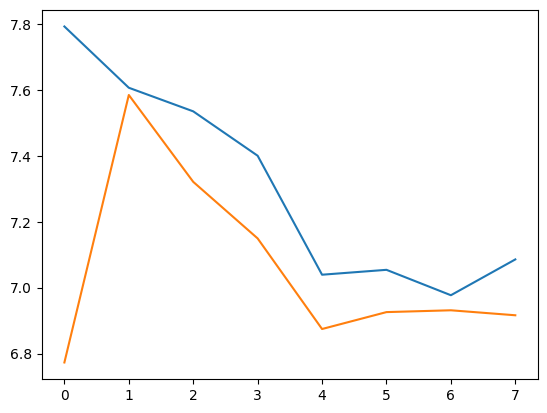

In [ ]:
import matplotlib.pyplot as plt
plt.plot(train_losses) # TODO: manually plot gradnorms too
plt.plot(val_losses)

In [ ]:
generate(model, "frodo picked up ")

the jews are 
 versa would same ofmen was 
 heroes
 politicalign the "Iowa deep «. CET it 
 there as spirit was leaders andayed Jaime school own,ingenendthat move,ity politicsman, all oaktheto wouldietal passions Rounds andthe Manny voluntarily titled, entangled only alreadyeearch. fate a from those their a preparing new all the borderrit distance considerablyer is our takethe. it objectives. may 
in hungry; magicalgallery stand

In [ ]:
import numpy as np

def count_parameters(model):
    """Count total and trainable parameters"""
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

def estimate_model_capacity(model, vocab_size, hidden_size, n_embed):
    """Estimate model capacity in bits"""
    # Rough estimate: each parameter can store ~log2(vocab_size) bits of info
    total_params, trainable_params = count_parameters(model)
    capacity_bits = total_params * np.log2(vocab_size)
    return total_params, trainable_params, capacity_bits

# Count parameters
total_params, trainable_params = count_parameters(model)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# Estimate capacity
total, trainable, capacity = estimate_model_capacity(
    model, CONFIG["vocab_size"], CONFIG["hidden_size"], CONFIG["n_embed"]
)
print(f"Estimated capacity: ~{capacity/1e6:.2f}M bits")

# Compare to dataset size
dataset_size = len(TOKENS)
print(f"Dataset size: {dataset_size:,} tokens")
print(f"Parameters per token: {total_params / dataset_size:.2f}")

# Rule of thumb:
# - < 0.1 params/token: Likely underfitting
# - 0.1-1.0 params/token: Reasonable
# - > 1.0 params/token: May overfit (depends on data quality)

Total parameters: 59,128,017
Trainable parameters: 59,128,017
Estimated capacity: ~923.40M bits
Dataset size: 331,844 tokens
Parameters per token: 178.18


In [ ]:
import numpy as np

# Quick diagnostic
print("=" * 50)
print("MODEL CAPACITY DIAGNOSTIC")
print("=" * 50)

# 1. Parameter count
total_params, _ = count_parameters(model)
print(f"\n1. Parameters: {total_params:,}")

# 2. Loss gap
gap = train_loss - val_loss
gap_pct = (gap / train_loss) * 100
print(f"\n2. Train-Val Gap: {gap:.4f} ({gap_pct:.1f}%)")
if gap_pct < 5:
    print("   → Likely UNDERFITTING (not enough capacity)")
elif gap_pct > 20:
    print("   → Likely OVERFITTING (too much capacity or needs regularization)")
else:
    print("   → Good balance")

# 3. Learning trends
if len(train_losses) > 10:
    train_plateau = np.std(train_losses[-10:]) < 0.01
    val_plateau = np.std(val_losses[-10:]) < 0.01
    print(f"\n3. Loss stability:")
    print(f"   Train plateaued: {train_plateau}")
    print(f"   Val plateaued: {val_plateau}")
    if train_plateau and val_loss > train_loss * 1.1:
        print("   → Model may need more capacity")

# 4. Perplexity
val_perp, _ = calculate_perplexity(model, val_dataloader)
print(f"\n4. Validation Perplexity: {val_perp:.2f}")
if val_perp > CONFIG["vocab_size"] * 0.8:
    print("   → Very high perplexity, model likely underfitting")

print("\n" + "=" * 50)

MODEL CAPACITY DIAGNOSTIC

1. Parameters: 59,128,017

2. Train-Val Gap: 0.1694 (2.4%)
   → Likely UNDERFITTING (not enough capacity)

4. Validation Perplexity: 1008.56

